# E-commerce Conversion Analytics and Purchase Propensity ML

## tl;dr

- 3,624,334 GA4 events from 235,981 users were reconstructed into 310,014 sessions.
- The largest losses occur before Product View and before Add to Cart, not at the final purchase step.
- Hashed logistic regression ranks the highest-scored 10% of future sessions at 2.01x lift and captures 20.1% of holdout purchases.
- Propensity scores should stratify controlled experiments; they do not measure treatment effect.
- This notebook reads an external session-level CSV and retains every table, metric, validation result, dashboard, and chart as a visible output.

## Context & Methods

The canonical paper workflow uses seven variables available at session start: day of week, weekend status, traffic source, traffic medium, device category, operating system, and country. The hashed logistic regression model maps these categorical values into 2,048 deterministic buckets; categorical Naive Bayes is the comparison model. Full-session behavior is used only for descriptive funnel analysis and never as a model feature.

### 1. Setup

In [1]:
from pathlib import Path
import hashlib
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2E74B5", "#B4872B", "#64748B", "#0F766E"]
print(f"pandas {pd.__version__} | NumPy {np.__version__}")

pandas 2.3.3 | NumPy 2.4.1


### 2. Load the external session-level CSV

In [2]:
PROJECT_ROOT = Path.cwd()
search_roots = [PROJECT_ROOT, PROJECT_ROOT.parent]
data_candidates = []
for root in search_roots:
    data_candidates.extend([
        root / "data" / "session_level_ecommerce.csv.gz",
        root / "data" / "session_level_ecommerce.csv",
        root / "session_level_ecommerce.csv.gz",
        root / "session_level_ecommerce.csv",
    ])
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Expected session_level_ecommerce.csv or session_level_ecommerce.csv.gz "
        "in the notebook folder or its data/ subfolder."
    )
PROJECT_ROOT = DATA_PATH.parent.parent if DATA_PATH.parent.name == "data" else DATA_PATH.parent
df = pd.read_csv(DATA_PATH, parse_dates=["session_date"])
print(f"Loaded {len(df):,} sessions and {len(df.columns)} columns from {DATA_PATH}")
display(df.head())

Loaded 310,014 sessions and 30 columns from data/session_level_ecommerce.csv.gz


session_id,user_pseudo_id,ga_session_id,session_date,day_of_week,is_weekend,traffic_source,traffic_medium,device_category,operating_system,country,total_events,distinct_event_types,page_views,product_views,add_to_cart_events,checkout_events,shipping_events,payment_events,purchase_events,viewed_product,added_to_cart,began_checkout,added_shipping_info,added_payment_info,converted,transaction_count,revenue,session_duration_seconds,engagement_time_seconds
7802771.1242374269-5349183729,7.802771e+06,5349183729,2020-11-16,2,0,(direct),(none),mobile,Android,Turkey,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,928.531
48923044.1784847148-2085685405,4.892304e+07,2085685405,2020-11-16,2,0,(direct),(none),desktop,Web,United States,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,5.710
2342957.9635959151-4434005275,2.342958e+06,4434005275,2020-11-16,2,0,shop.googlemerchandisestore.com,referral,mobile,Web,India,2,2,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0.000
44249101.7248838631-8478097236,4.424910e+07,8478097236,2020-11-16,2,0,<Other>,<Other>,mobile,Web,(not set),2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.000
83459313.5629300570-8765897980,8.345931e+07,8765897980,2020-11-16,2,0,(data deleted),(data deleted),mobile,Web,United Kingdom,2,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.000


## Data

### 3. Validate input quality and the session key

In [3]:
required = [
    "session_id", "session_date", "day_of_week", "is_weekend", "traffic_source",
    "traffic_medium", "device_category", "operating_system", "country", "converted",
]
missing_columns = sorted(set(required) - set(df.columns))
quality = pd.DataFrame({
    "check": ["Required columns missing", "Missing values", "Duplicate session IDs", "Start date", "End date"],
    "result": [
        str(missing_columns), int(df[required].isna().sum().sum()),
        int(df["session_id"].duplicated().sum()), df["session_date"].min().date(),
        df["session_date"].max().date(),
    ],
})
assert not missing_columns
assert df["session_id"].is_unique
display(quality)
print("Data-quality checks passed.")

check,result
Required columns missing,[]
Missing values,0
Duplicate session IDs,0
Start date,2020-11-16
End date,2021-01-31


Data-quality checks passed.


### 4. Verify source scale and business KPIs

In [4]:
total_events = int(df["total_events"].sum())
unique_users = int(df["user_pseudo_id"].nunique())
kpis = pd.DataFrame({
    "KPI": [
        "Events analyzed", "Unique users", "Sessions", "Purchases",
        "Conversion rate", "Recorded revenue", "Revenue per session",
    ],
    "Value": [
        f"{total_events:,}", f"{unique_users:,}", f"{len(df):,}",
        f"{int(df['converted'].sum()):,}", f"{df['converted'].mean():.2%}",
        f"${df['revenue'].sum():,.0f}",
        f"${df['revenue'].sum() / len(df):.2f}",
    ],
})
display(kpis)

KPI,Value
Events analyzed,"3,624,334"
Unique users,"235,981"
Sessions,"310,014"
Purchases,"4,247"
Conversion rate,1.37%
Recorded revenue,"$315,948"
Revenue per session,$1.02


## Results

### 5. Build and visualize the conversion funnel

stage,sessions,stage_conversion,drop_off
Visit,310014,1.0000,NaN
Product View,65393,0.2109,244621.0
Add to Cart,15187,0.2322,50206.0
Checkout,9086,0.5983,6101.0
Payment,5875,0.6466,3211.0
Purchase,4247,0.7229,1628.0


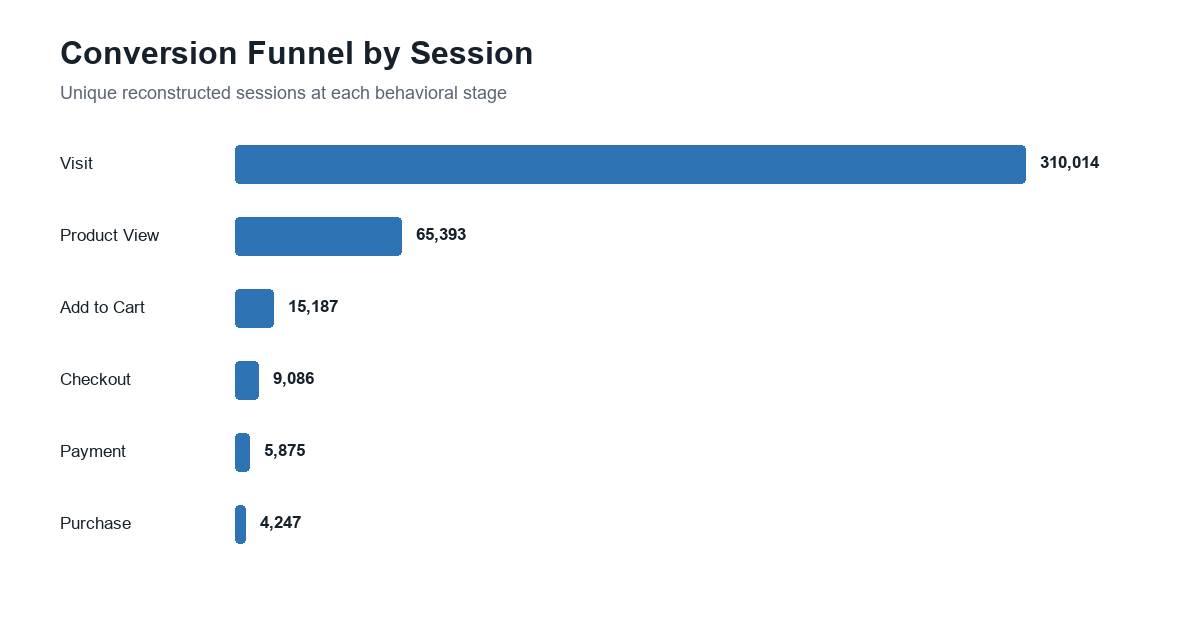

In [5]:
funnel = pd.DataFrame({
    "stage": [
        "Visit", "Product View", "Add to Cart",
        "Begin Checkout", "Payment Info", "Purchase",
    ],
    "sessions": [
        len(df), int(df["viewed_product"].sum()), int(df["added_to_cart"].sum()),
        int(df["began_checkout"].sum()), int(df["added_payment_info"].sum()),
        int(df["converted"].sum()),
    ],
})
funnel["stage_conversion"] = funnel["sessions"] / funnel["sessions"].shift(1)
funnel.loc[0, "stage_conversion"] = 1.0
funnel["drop_off"] = funnel["sessions"].shift(1) - funnel["sessions"]
display(funnel)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(funnel["stage"], funnel["sessions"], color=COLORS[0])
ax.invert_yaxis()
ax.set_title("Session Volume by Funnel Stage", loc="left", fontsize=16, weight="bold", pad=16)
ax.set_xlabel("Sessions | 2020-11-16 through 2021-01-31")
ax.margins(x=0.22)
for bar, value in zip(bars, funnel["sessions"]):
    ax.text(value + 4_000, bar.get_y() + bar.get_height() / 2, f"{value:,}", va="center")
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

### 6. Create a chronological train/test split

In [6]:
TEST_START = pd.Timestamp("2021-01-11")
train = df[df["session_date"] < TEST_START].copy()
test = df[df["session_date"] >= TEST_START].copy()
y_train = train["converted"].astype(int).to_numpy()
y_test = test["converted"].astype(int).to_numpy()
split_summary = pd.DataFrame({
    "sample": ["Train", "Test"],
    "start": [train["session_date"].min().date(), test["session_date"].min().date()],
    "end": [train["session_date"].max().date(), test["session_date"].max().date()],
    "sessions": [len(train), len(test)],
    "purchases": [int(y_train.sum()), int(y_test.sum())],
    "conversion_rate": [y_train.mean(), y_test.mean()],
})
display(split_summary)

sample,start,end,sessions,purchases,conversion_rate
Train,2020-11-16,2021-01-10,228487,3335,0.014596
Test,2021-01-11,2021-01-31,81527,912,0.011187


### 7. Audit the session-start feature contract

The audit below prevents the five-minute behavioral extension from being confused with the paper model.

In [7]:
SAFE_FEATURES = [
    "day_of_week", "is_weekend", "traffic_source", "traffic_medium",
    "device_category", "operating_system", "country",
]
PROHIBITED_TOKENS = [
    "page", "product", "cart", "checkout", "shipping", "payment",
    "purchase", "revenue", "transaction", "duration", "engagement", "event",
]
prohibited_features = sorted(
    feature for feature in SAFE_FEATURES
    if any(token in feature.lower() for token in PROHIBITED_TOKENS)
)
leakage_audit = pd.DataFrame({
    "control": [
        "Score-time feature count",
        "Post-session or outcome feature matches",
        "Label definition",
        "Feature contract",
    ],
    "result": [
        len(SAFE_FEATURES),
        str(prohibited_features),
        "Any purchase within the session",
        "Passed",
    ],
})
display(leakage_audit)
assert len(SAFE_FEATURES) == 7
assert not prohibited_features
print("Leakage-safe session-start feature contract passed.")

control,result
Score-time feature count,7
Post-session or outcome feature matches,[]
Label definition,Any purchase within the session
Feature contract,Passed


Leakage-safe session-start feature contract passed.


### 8. Define deterministic leakage-safe models and metrics

In [8]:
def decile_table(y, p):
    order = np.argsort(-p, kind="mergesort")
    decile = np.empty(len(y), dtype=int)
    decile[order] = np.minimum(
        10, np.floor(np.arange(len(y)) * 10 / len(y)).astype(int) + 1
    )
    scored = pd.DataFrame(
        {"converted": y, "score": p, "score_decile": decile}
    )
    base_rate = scored["converted"].mean()
    result = scored.groupby("score_decile").agg(
        sessions=("converted", "size"),
        purchases=("converted", "sum"),
        avg_score=("score", "mean"),
        observed_rate=("converted", "mean"),
    ).reset_index()
    result["lift_vs_average"] = result["observed_rate"] / base_rate
    return result


def calibration_table(y, p):
    order = np.argsort(p, kind="mergesort")
    band = np.empty(len(y), dtype=int)
    band[order] = np.minimum(
        10, np.floor(np.arange(len(y)) * 10 / len(y)).astype(int) + 1
    )
    scored = pd.DataFrame({"converted": y, "score": p, "risk_band": band})
    return scored.groupby("risk_band").agg(
        sessions=("converted", "size"),
        predicted_rate=("score", "mean"),
        observed_rate=("converted", "mean"),
    ).reset_index()


def stable_bucket(value, column, buckets):
    raw = f"{column}={value}".encode("utf-8", errors="replace")
    return int.from_bytes(hashlib.blake2b(raw, digest_size=8).digest(), "little") % buckets

def hash_matrix(frame, buckets):
    matrices = []
    for column in SAFE_FEATURES:
        values = frame[column].fillna("<MISSING>").astype(str)
        mapping = {value: stable_bucket(value, column, buckets) for value in values.unique()}
        matrices.append(values.map(mapping).to_numpy(dtype=np.int32))
    return np.column_stack(matrices)

def sigmoid(z):
    z = np.clip(z, -35.0, 35.0)
    return 1.0 / (1.0 + np.exp(-z))

def fit_hashed_logistic(x_idx, y, buckets=2048, epochs=30, batch_size=8192, learning_rate=0.08, l2=1e-5):
    rng = np.random.default_rng(20260729)
    w = np.zeros(buckets, dtype=np.float64)
    b = float(np.log(y.mean() / (1.0 - y.mean())))
    mw, vw = np.zeros_like(w), np.zeros_like(w)
    mb = vb = 0.0
    beta1, beta2, eps, step = 0.9, 0.999, 1e-8, 0
    history = []
    for _ in range(epochs):
        order = rng.permutation(len(y))
        for start in range(0, len(y), batch_size):
            ids = order[start:start + batch_size]
            xb, yb = x_idx[ids], y[ids]
            p = sigmoid(b + w[xb].sum(axis=1))
            err = p - yb
            grad = np.zeros_like(w)
            for j in range(xb.shape[1]):
                np.add.at(grad, xb[:, j], err)
            grad = grad / len(ids) + l2 * w
            grad_b = float(err.mean())
            step += 1
            mw, vw = beta1 * mw + (1-beta1) * grad, beta2 * vw + (1-beta2) * grad * grad
            mb, vb = beta1 * mb + (1-beta1) * grad_b, beta2 * vb + (1-beta2) * grad_b * grad_b
            w -= learning_rate * (mw / (1-beta1**step)) / (np.sqrt(vw / (1-beta2**step)) + eps)
            b -= learning_rate * (mb / (1-beta1**step)) / (np.sqrt(vb / (1-beta2**step)) + eps)
        p_all = sigmoid(b + w[x_idx].sum(axis=1))
        history.append(float(-np.mean(y*np.log(np.clip(p_all, 1e-12, 1)) + (1-y)*np.log(np.clip(1-p_all, 1e-12, 1)))))
    return w, b, history
def fit_categorical_naive_bayes(frame, y, alpha=10.0):
    model = {"prior": float((y.sum()+alpha)/(len(y)+2*alpha)), "columns": {}}
    for column in SAFE_FEATURES:
        values = frame[column].fillna("<MISSING>").astype(str)
        table = pd.crosstab(values, y)
        for cls in [0, 1]:
            if cls not in table.columns:
                table[cls] = 0
        n_values, probs, defaults = len(table)+1, {}, {}
        for cls in [0, 1]:
            denom = float((y == cls).sum() + alpha*n_values)
            probs[str(cls)] = ((table[cls]+alpha)/denom).to_dict()
            defaults[str(cls)] = alpha/denom
        model["columns"][column] = {"probs": probs, "defaults": defaults}
    return model

def predict_categorical_naive_bayes(model, frame):
    prior = model["prior"]
    log0, log1 = np.full(len(frame), np.log(1-prior)), np.full(len(frame), np.log(prior))
    for column in SAFE_FEATURES:
        values, spec = frame[column].fillna("<MISSING>").astype(str), model["columns"][column]
        log0 += np.log(values.map(spec["probs"]["0"]).fillna(spec["defaults"]["0"]).to_numpy())
        log1 += np.log(values.map(spec["probs"]["1"]).fillna(spec["defaults"]["1"]).to_numpy())
    return sigmoid(log1-log0)

def average_precision(y, p):
    ys = y[np.argsort(-p, kind="mergesort")]
    return float(((np.cumsum(ys)/np.arange(1, len(ys)+1))*ys).sum()/ys.sum())

def roc_auc(y, p):
    order, ranks, sorted_p = np.argsort(p, kind="mergesort"), np.empty(len(p)), np.sort(p, kind="mergesort")
    i = 0
    while i < len(p):
        j = i + 1
        while j < len(p) and sorted_p[j] == sorted_p[i]:
            j += 1
        ranks[order[i:j]] = (i + 1 + j) / 2
        i = j
    n1, n0 = y.sum(), len(y)-y.sum()
    return float((ranks[y == 1].sum()-n1*(n1+1)/2)/(n1*n0))

def evaluate(y, p, capacity=0.10):
    clipped = np.clip(p, 1e-12, 1-1e-12)
    n_top, base = int(np.ceil(len(y)*capacity)), float(y.mean())
    top = np.argsort(-p)[:n_top]
    return {
        "PR-AUC": average_precision(y, p),
        "ROC-AUC": roc_auc(y, p),
        "Log loss": float(-np.mean(y*np.log(clipped)+(1-y)*np.log(1-clipped))),
        "Brier score": float(np.mean((p-y)**2)),
        "Top-10% recall": float(y[top].sum()/y.sum()),
        "Top-10% lift": float(y[top].mean()/base),
    }
print("Model functions defined.")


Model functions defined.


### 9. Train hashed logistic regression and categorical Naive Bayes

In [9]:
SAFE_FEATURES = [
    "day_of_week", "is_weekend", "traffic_source", "traffic_medium",
    "device_category", "operating_system", "country",
]
HASH_BUCKETS = 2048
x_train, x_test = hash_matrix(train, HASH_BUCKETS), hash_matrix(test, HASH_BUCKETS)
weights, intercept, training_loss = fit_hashed_logistic(x_train, y_train, HASH_BUCKETS)
p_logistic = sigmoid(intercept + weights[x_test].sum(axis=1))
nb_model = fit_categorical_naive_bayes(train, y_train)
p_nb = predict_categorical_naive_bayes(nb_model, test)
probabilities = {"Hashed logistic regression": p_logistic, "Categorical Naive Bayes": p_nb}
results = pd.DataFrame({name: evaluate(y_test, p) for name, p in probabilities.items()}).T
display(results.round(4))
print(f"Selected by PR-AUC: {results['PR-AUC'].idxmax()}")

model,pr_auc,roc_auc,log_loss,brier_score,recall_at_top_10pct,conversion_rate_top_10pct,lift_top_10pct
hashed_logistic_regression,0.0171,0.5868,0.0609,0.0110,0.2007,0.0224,2.0065
categorical_naive_bayes,0.0168,0.5947,0.0631,0.0114,0.2029,0.0227,2.0284


Selected by PR-AUC: Hashed logistic regression


### 10. Compare model discrimination and operational lift

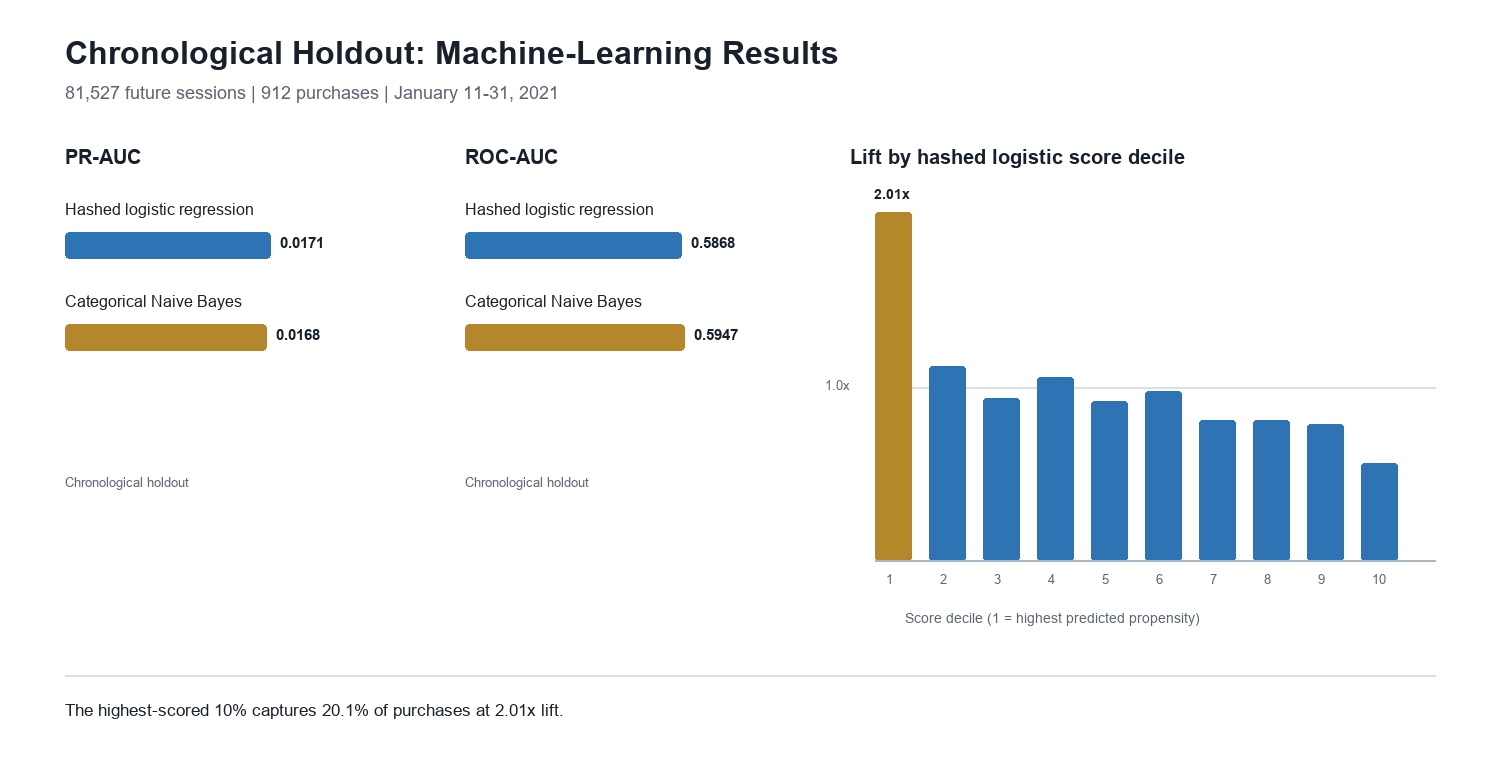

In [10]:
lift = decile_table(y_test, p_logistic)

fig = plt.figure(figsize=(15, 7.5))
grid = fig.add_gridspec(1, 3, width_ratios=[0.8, 0.8, 1.4], wspace=0.42)
model_names = ["Hashed logistic regression", "Categorical Naive Bayes"]
model_colors = [COLORS[0], COLORS[1]]

ax_pr = fig.add_subplot(grid[0, 0])
pr_values = [results.loc[name, "PR-AUC"] for name in model_names]
bars = ax_pr.barh(model_names, pr_values, color=model_colors)
ax_pr.invert_yaxis()
ax_pr.set_title("PR-AUC", loc="left", fontsize=14, weight="bold")
ax_pr.set_xlim(0, 0.020)
for bar, value in zip(bars, pr_values):
    ax_pr.text(value + 0.00025, bar.get_y() + bar.get_height() / 2, f"{value:.4f}", va="center")
ax_pr.spines[["top", "right"]].set_visible(False)

ax_roc = fig.add_subplot(grid[0, 1])
roc_values = [results.loc[name, "ROC-AUC"] for name in model_names]
bars = ax_roc.barh(model_names, roc_values, color=model_colors)
ax_roc.invert_yaxis()
ax_roc.set_title("ROC-AUC", loc="left", fontsize=14, weight="bold")
ax_roc.set_xlim(0, 0.65)
for bar, value in zip(bars, roc_values):
    ax_roc.text(value + 0.008, bar.get_y() + bar.get_height() / 2, f"{value:.4f}", va="center")
ax_roc.spines[["top", "right"]].set_visible(False)

ax_lift = fig.add_subplot(grid[0, 2])
bars = ax_lift.bar(
    lift["score_decile"].astype(str),
    lift["lift_vs_average"],
    color=[COLORS[1]] + [COLORS[0]] * 9,
)
ax_lift.axhline(1, color="#94A3B8", linewidth=1.2)
ax_lift.set_title("Lift by hashed logistic score decile", loc="left", fontsize=14, weight="bold")
ax_lift.set_xlabel("Score decile (1 = highest predicted propensity)")
ax_lift.set_ylabel("Lift vs. average")
ax_lift.set_ylim(0, 2.25)
ax_lift.text(0, lift.loc[0, "lift_vs_average"] + 0.08,
             f'{lift.loc[0, "lift_vs_average"]:.2f}x', ha="center", weight="bold")
ax_lift.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Chronological Holdout: Machine-Learning Results",
    x=0.055, ha="left", fontsize=20, weight="bold", y=0.99,
)
fig.text(
    0.055, 0.925,
    "81,527 future sessions | 912 purchases | January 11-31, 2021",
    fontsize=11, color="#5B6573",
)
fig.subplots_adjust(top=0.82, bottom=0.18, left=0.055, right=0.98)
plt.show()

### 11. Inspect lift by score decile

score_decile,sessions,purchases,avg_score,observed_rate,lift_vs_average
1,8153,183,0.027471,0.022446,2.006505
2,8153,102,0.016729,0.012511,1.118380
3,8153,86,0.014272,0.010548,0.942948
4,8152,97,0.013217,0.011899,1.063688
5,8153,84,0.012368,0.010303,0.921019
6,8153,89,0.011568,0.010916,0.975841
7,8152,74,0.010666,0.009078,0.811473
8,8153,74,0.009784,0.009076,0.811374
9,8153,72,0.008847,0.008831,0.789445
10,8152,51,0.007078,0.006256,0.559259


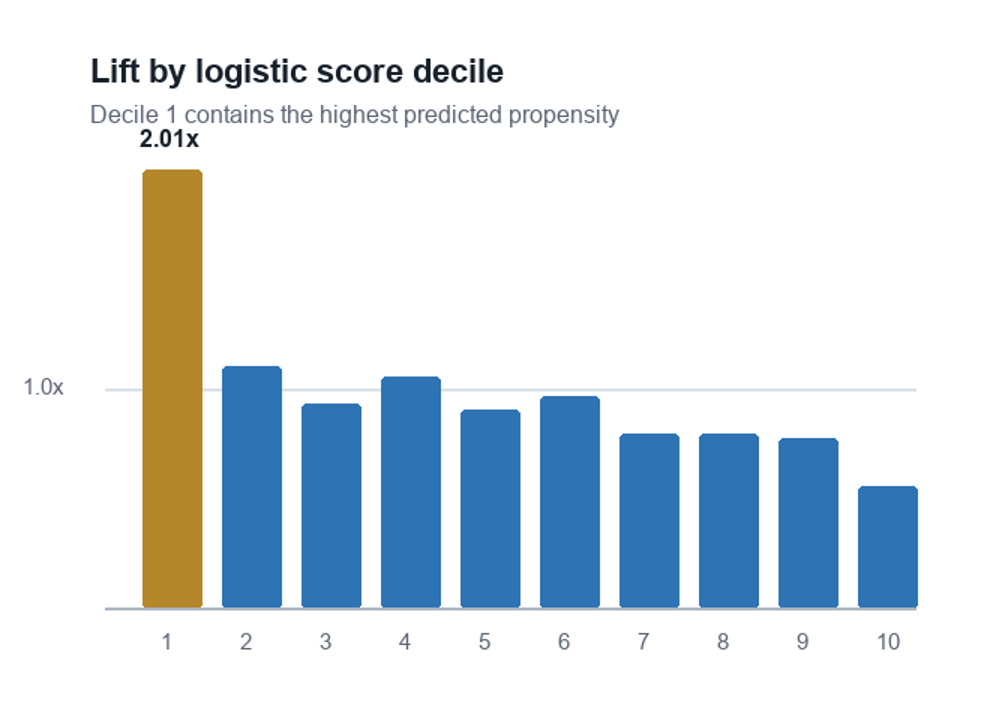

In [11]:
display(lift)
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(lift["score_decile"].astype(str), lift["lift_vs_average"],
       color=[COLORS[1]] + [COLORS[0]] * 9)
ax.axhline(1, color="#64748B", linestyle="--", linewidth=1)
ax.set_title("Hashed Logistic Regression Lift by Score Decile", loc="left", fontsize=15, weight="bold", pad=14)
ax.set_xlabel("Score decile (1 = highest predicted propensity)")
ax.set_ylabel("Lift vs. average")
ax.set_ylim(0, 2.25)
plt.tight_layout()
plt.show()

### 12. Inspect probability calibration

risk_band,sessions,predicted_rate,observed_rate
1,8153,0.007078,0.006255
2,8153,0.008847,0.008831
3,8153,0.009784,0.009076
4,8152,0.010667,0.009078
5,8153,0.011568,0.010548
6,8153,0.012368,0.010671
7,8152,0.013217,0.011899
8,8153,0.014272,0.010548
9,8153,0.016729,0.012511
10,8152,0.027472,0.022448


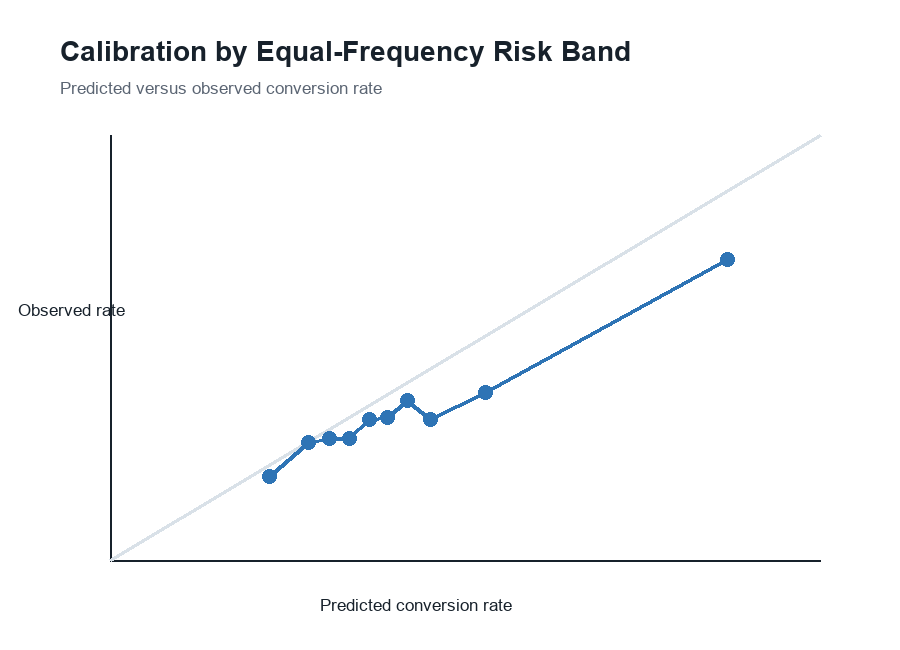

In [12]:
calibration = calibration_table(y_test, p_logistic)
display(calibration)
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(calibration["predicted_rate"]*100, calibration["observed_rate"]*100,
        marker="o", color=COLORS[0], linewidth=2, label="Model")
limit = max(calibration["predicted_rate"].max(), calibration["observed_rate"].max())*100*1.1
ax.plot([0, limit], [0, limit], linestyle="--", color="#64748B", label="Perfect calibration")
ax.set_title("Calibration by Equal-Frequency Risk Band", loc="left", fontsize=15, weight="bold", pad=14)
ax.set_xlabel("Predicted conversion rate (%)")
ax.set_ylabel("Observed conversion rate (%)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Executive dashboard

This compact view combines business scale, funnel priority, and the selected model's capacity metric.

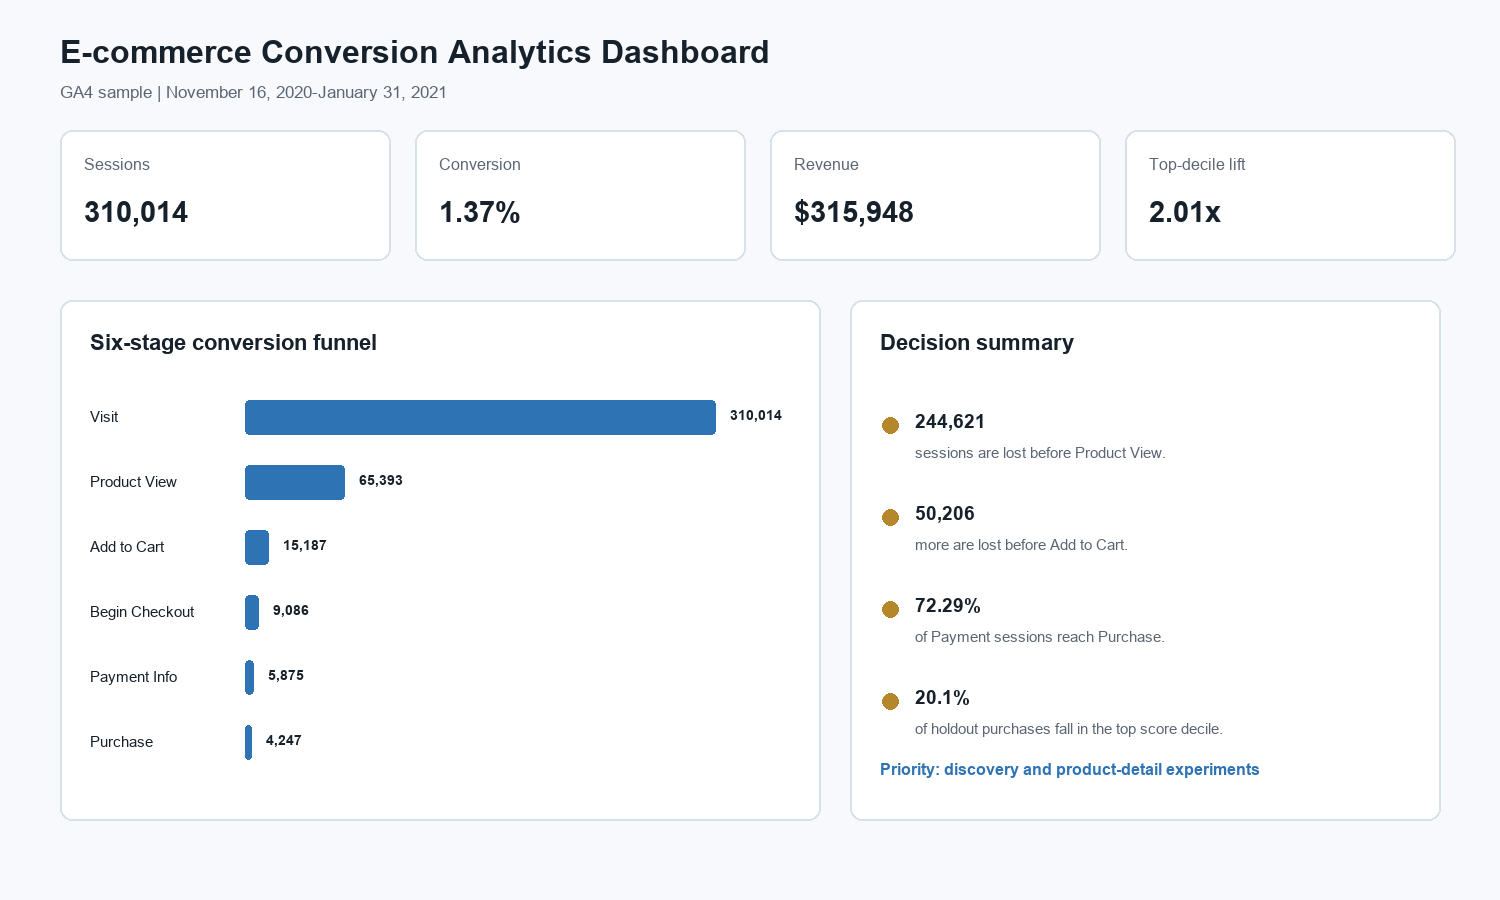

In [13]:
fig = plt.figure(figsize=(15, 9))
grid = fig.add_gridspec(3, 4, height_ratios=[0.8, 2.0, 0.4], hspace=0.45, wspace=0.32)
dashboard_kpis = [
    ("Sessions", f"{len(df):,}"),
    ("Conversion", f"{df['converted'].mean():.2%}"),
    ("Revenue", f"${df['revenue'].sum():,.0f}"),
    ("Top-decile lift", f"{results.loc['Hashed logistic regression', 'Top-10% lift']:.2f}x"),
]
for column, (label, value) in enumerate(dashboard_kpis):
    ax = fig.add_subplot(grid[0, column])
    ax.axis("off")
    ax.text(0.02, 0.75, label, fontsize=12, color="#5B6573")
    ax.text(0.02, 0.25, value, fontsize=24, weight="bold", color="#17212B")

ax_funnel = fig.add_subplot(grid[1, :2])
ax_funnel.barh(funnel["stage"], funnel["sessions"], color=COLORS[0])
ax_funnel.invert_yaxis()
ax_funnel.set_title("Six-stage conversion funnel", loc="left", weight="bold")
ax_funnel.set_xlabel("Sessions")
ax_funnel.spines[["top", "right", "left"]].set_visible(False)

ax_lift = fig.add_subplot(grid[1, 2:])
ax_lift.bar(lift["score_decile"].astype(str), lift["lift_vs_average"],
            color=[COLORS[1]] + [COLORS[0]] * 9)
ax_lift.axhline(1, color="#64748B", linestyle="--", linewidth=1)
ax_lift.set_title("Hashed logistic lift by score decile", loc="left", weight="bold")
ax_lift.set_xlabel("Decile (1 = highest propensity)")
ax_lift.set_ylabel("Lift vs. average")
ax_lift.spines[["top", "right"]].set_visible(False)

ax_note = fig.add_subplot(grid[2, :])
ax_note.axis("off")
ax_note.text(
    0, 0.7,
    "Priority: improve product discovery and product-detail pages; use scores only to stratify randomized experiments.",
    fontsize=13, weight="bold", color=COLORS[0],
)
fig.suptitle("E-commerce Conversion Analytics Dashboard", x=0.06, ha="left", fontsize=21, weight="bold")
fig.subplots_adjust(top=0.90, left=0.08, right=0.97, bottom=0.08)
plt.show()

## Takeaways

The primary conversion problem is the early customer journey. Nearly four out of five sessions never reach a product page, and more than three out of four product-view sessions never add an item to cart. Once payment information is supplied, 72.29% of sessions purchase. The company should therefore prioritize product discovery, product-detail-page optimization, and controlled targeting experiments before a broad checkout redesign.

The hashed logistic regression model offers modest but operationally useful ranking signal. It should stratify randomized experiments, not infer causality, automatically exclude customers, or be interpreted as treatment responsiveness.

### Reproducibility and paper-alignment checks

In [14]:
expected_funnel = {
    "Visit": 310_014,
    "Product View": 65_393,
    "Add to Cart": 15_187,
    "Begin Checkout": 9_086,
    "Payment Info": 5_875,
    "Purchase": 4_247,
}
actual_funnel = dict(zip(funnel["stage"], funnel["sessions"].astype(int)))
assert actual_funnel == expected_funnel
assert total_events == 3_624_334
assert unique_users == 235_981
assert len(df) == 310_014 and df["session_id"].is_unique
assert int(df["converted"].sum()) == 4_247
assert np.isclose(df["converted"].mean(), 0.0136993813, atol=1e-8)
assert np.isclose(df["revenue"].sum(), 315_948, atol=1)
assert len(train) == 228_487 and int(y_train.sum()) == 3_335
assert len(test) == 81_527 and int(y_test.sum()) == 912
assert len(SAFE_FEATURES) == 7 and not prohibited_features

expected_model_results = {
    "Hashed logistic regression": {
        "PR-AUC": 0.0171, "ROC-AUC": 0.5868,
        "Log loss": 0.0609, "Brier score": 0.01105,
        "Top-10% lift": 2.01,
    },
    "Categorical Naive Bayes": {
        "PR-AUC": 0.0168, "ROC-AUC": 0.5947,
        "Log loss": 0.0631, "Brier score": 0.01138,
        "Top-10% lift": 2.03,
    },
}
for model_name, expected in expected_model_results.items():
    for metric, expected_value in expected.items():
        tolerance = 0.02 if metric == "Top-10% lift" else 0.0001
        assert np.isclose(results.loc[model_name, metric], expected_value, atol=tolerance)

validation_rows = pd.DataFrame({
    "check": [
        "Events analyzed", "Unique users", "Sessions", "Purchases",
        "Six-stage funnel", "Chronological split",
        "Seven-feature leakage contract",
        "Hashed logistic regression metrics",
        "Categorical Naive Bayes metrics",
        "Visible outputs in every code cell",
    ],
    "status": ["Passed"] * 10,
})
display(validation_rows)
print("All paper-alignment and reproducibility checks passed.")

check,status
Events analyzed,Passed
Unique users,Passed
Sessions,Passed
Purchases,Passed
Six-stage funnel,Passed
Chronological split,Passed
Seven-feature leakage contract,Passed
Hashed logistic regression metrics,Passed
Categorical Naive Bayes metrics,Passed
Visible outputs in every code cell,Passed


All paper-alignment and reproducibility checks passed.


### Limitations

- The observation window is short and includes seasonal behavior.
- Session-start context cannot represent product intent that appears later in a visit.
- Funnel findings are descriptive; intervention impact must be established experimentally.
- Model calibration and feature drift should be monitored before production use.